In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

from sklearn.utils import resample

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("../data/updated/upgraded_customer_retention.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,numTechTickets,Churn,customer_lifetime_value,revenue_tier,support_frustration_score,service_adoption_score,billing_risk_score,engagement_score,high_value_churn_flag,churn_risk_segment
0,7590-VHVEG,Female,0,Yes,No,1,0,No phone service,DSL,0,...,0,No,29.85,Bronze,0,1,6,5.5,0,Medium Risk
1,5575-GNVDE,Male,0,No,No,34,1,No,DSL,1,...,0,No,1936.30,Silver,0,3,0,32.0,0,Low Risk
2,3668-QPYBK,Male,0,No,No,2,1,No,DSL,1,...,0,Yes,107.70,Bronze,0,3,4,16.0,0,Medium Risk
3,7795-CFOCW,Male,0,No,No,45,0,No phone service,DSL,1,...,3,No,1903.50,Silver,6,3,0,25.5,0,Medium Risk
4,9237-HQITU,Female,0,No,No,2,1,No,Fiber optic,0,...,0,Yes,141.40,Bronze,0,1,6,6.0,0,Medium Risk


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   str    
 1   gender                     7043 non-null   str    
 2   SeniorCitizen              7043 non-null   int64  
 3   Partner                    7043 non-null   str    
 4   Dependents                 7043 non-null   str    
 5   tenure                     7043 non-null   int64  
 6   PhoneService               7043 non-null   int64  
 7   MultipleLines              7043 non-null   str    
 8   InternetService            7043 non-null   str    
 9   OnlineSecurity             7043 non-null   int64  
 10  OnlineBackup               7043 non-null   int64  
 11  DeviceProtection           7043 non-null   int64  
 12  TechSupport                7043 non-null   int64  
 13  StreamingTV                7043 non-null   int64  
 14  Str

In [6]:
#seperate the target
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [7]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [8]:
#dropping id columns
df.drop(
    columns=["customerID"],
    inplace=True
)

In [10]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,numTechTickets,Churn,customer_lifetime_value,revenue_tier,support_frustration_score,service_adoption_score,billing_risk_score,engagement_score,high_value_churn_flag,churn_risk_segment
0,Female,0,Yes,No,1,0,No phone service,DSL,0,1,...,0,0,29.85,Bronze,0,1,6,5.5,0,Medium Risk
1,Male,0,No,No,34,1,No,DSL,1,0,...,0,0,1936.30,Silver,0,3,0,32.0,0,Low Risk
2,Male,0,No,No,2,1,No,DSL,1,1,...,0,1,107.70,Bronze,0,3,4,16.0,0,Medium Risk
3,Male,0,No,No,45,0,No phone service,DSL,1,0,...,3,0,1903.50,Silver,6,3,0,25.5,0,Medium Risk
4,Female,0,No,No,2,1,No,Fiber optic,0,0,...,0,1,141.40,Bronze,0,1,6,6.0,0,Medium Risk


In [8]:
#avg monthly spend
df["avg_monthly_spend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

In [9]:
#customer tenure grp
conditions = [
    df["tenure"] < 12,

    (df["tenure"] >= 12)
    &
    (df["tenure"] < 36),

    (df["tenure"] >= 36)
    &
    (df["tenure"] < 60),

    df["tenure"] >= 60
]

choices = [
    "New",
    "Growing",
    "Loyal",
    "VIP"
]

df["tenure_group"] = np.select(
    conditions,
    choices,
    default='Unknown'
)

In [10]:
#ticket intensity = Frequent issues relative to customer age
df["ticket_intensity"] = (
    (
        df["numAdminTickets"]
        +
        df["numTechTickets"]
    )
    /
    (df["tenure"] + 1)
)

In [11]:
#revenue efficiency = Higher value with fewer services may indicate upsell potential or dependence on a single service.
df["revenue_efficiency"] = (
    df["customer_lifetime_value"]
    /
    (df["service_adoption_score"] + 1)
)

In [12]:
#Customer Health Score 
health_features = [
    "engagement_score",
    "service_adoption_score",
    "billing_risk_score",
    "support_frustration_score"
]

In [13]:
from sklearn.preprocessing import MinMaxScaler

health_scaler = MinMaxScaler()

scaled = health_scaler.fit_transform(
    df[health_features]
)

health = pd.DataFrame(
    scaled,
    columns=health_features
)

In [14]:
#Encode Categorical Variables
cat_cols = df.select_dtypes(
    include="object"
).columns
cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'MultipleLines',
       'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Churn', 'revenue_tier', 'churn_risk_segment', 'tenure_group'],
      dtype='str')

In [15]:
#Encode binary categories first
binary_cols = [
    col
    for col in cat_cols
    if df[col].nunique()==2
]
binary_cols

['gender', 'Partner', 'Dependents', 'PaperlessBilling', 'Churn']

In [16]:
#encode
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [17]:
#multi class coding
multi_cols = [
    col
    for col in cat_cols
    if df[col].nunique()>2
]
df = pd.get_dummies(
    df,
    columns=multi_cols,
    drop_first=True
)

In [ ]:
#Separate Features
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]


0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [19]:
#Feature Scaling
numeric_cols = X.select_dtypes(
    include=np.number
).columns

scaler = StandardScaler()

X[numeric_cols] = scaler.fit_transform(
    X[numeric_cols]
)

In [25]:
#Feature Selection = identify strongest predictors
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=20
)

selector.fit(
    X,
    y
)

scores = pd.DataFrame({
    "Feature":X.columns,
    "Score":selector.scores_
})

scores = scores.sort_values(
    by="Score",
    ascending=False
)

scores.head(20)

selected = scores.head(20)["Feature"]

X = X[selected]


In [26]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
print(X_train.shape)
print(X_test.shape)

(5634, 20)
(1409, 20)


In [28]:
y_train.value_counts()

Churn
0    4139
1    1495
Name: count, dtype: int64

In [29]:
from imblearn.over_sampling import SMOTE

In [30]:
smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

In [31]:
y_train_balanced.value_counts()

Churn
0    4139
1    4139
Name: count, dtype: int64

In [32]:
ml_ready = X.copy()
ml_ready["Churn"] = y

ml_ready.to_csv(
    "../data/updated/ml_ready_dataset.csv",
    index=False
)

In [33]:
X_train_balanced.to_csv(
    "../data/updated/X_train.csv",
    index=False
)

X_test.to_csv(
    "../data/updated/X_test.csv",
    index=False
)

y_train_balanced.to_csv(
    "../data/updated/y_train.csv",
    index=False
)

y_test.to_csv(
    "../data/updated/y_test.csv",
    index=False
)

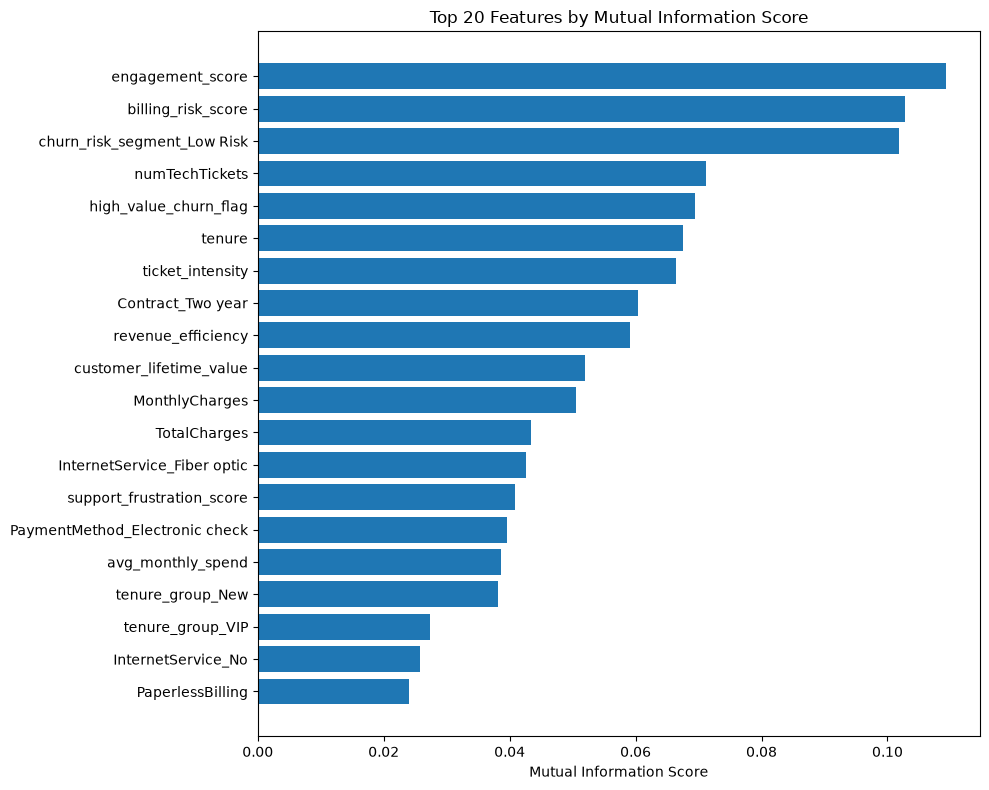

In [34]:
#Feature Importance Report
feature_report = scores.copy()

feature_report.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

import matplotlib.pyplot as plt

top20 = scores.head(20).sort_values("Score")

plt.figure(figsize=(10,8))
plt.barh(top20["Feature"], top20["Score"])

plt.title("Top 20 Features by Mutual Information Score")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

In [35]:
# Goal

# We'll perform four tasks:

#  Remove target leakage (high_value_churn_flag)
#  Remove redundant engineered feature (churn_risk_segment)
#  Check multicollinearity using Variance Inflation Factor (VIF)
#  Re-run feature selection and verify the final feature set

In [36]:
# Create a Safety Copy
# Create a copy for optimization
df_final = df.copy()

print(df_final.shape)

(7043, 7085)


In [38]:
#Remove Target Leakage
print(df_final.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets', 'numTechTickets', 'Churn', 'customer_lifetime_value', 'support_frustration_score', 'service_adoption_score', 'billing_risk_score', 'engagement_score', 'high_value_churn_flag', 'avg_monthly_spend', 'ticket_intensity', 'revenue_efficiency', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF', 'customerID_0013-EXCHZ', 'customerID_0013-MHZWF', 'customerID_0013-SMEOE', 'customerID_0014-BMAQU', 'customerID_0015-UOCOJ', 'customerID_0016-QLJIS', 'customerID_0017-DINOC', 'customerID_0017-IUDMW', 'customerID_0018-NYROU', 'customerID_0019-EFAEP', 'customerID_0019-GFNTW', 'customerID_0020-INWCK', 'customerID_0020-JDNXP', 'customerID_0021-IKXGC', 'customerID_0022-TCJCI', 'customerID_0023-HGHWL', 'customerID_0023-UYUPN', 'custo

In [39]:
if "high_value_churn_flag" in df_final.columns:
    df_final.drop(columns="high_value_churn_flag", inplace=True)
    print("high_value_churn_flag removed")
else:
    print("Column already removed")

high_value_churn_flag removed


In [40]:
"high_value_churn_flag" in df_final.columns

False

In [41]:
#Remove Churn Risk Segment
[col for col in df_final.columns if "churn_risk" in col.lower()]

['churn_risk_segment_Low Risk', 'churn_risk_segment_Medium Risk']

In [43]:
risk_cols = [
    col
    for col in df_final.columns
    if "churn_risk_segment" in col
]

print(risk_cols)
df_final.drop(columns=risk_cols, inplace=True)

['churn_risk_segment_Low Risk', 'churn_risk_segment_Medium Risk']


In [44]:
[col for col in df_final.columns if "churn_risk" in col.lower()]

[]

Check Multicollinearity
Now we determine whether

TotalCharges
MonthlyCharges
customer_lifetime_value
tenure

are telling the model almost the same thing.

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
numeric_df = df_final.select_dtypes(include="number")

numeric_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,numTechTickets,Churn,customer_lifetime_value,support_frustration_score,service_adoption_score,billing_risk_score,engagement_score,avg_monthly_spend,ticket_intensity,revenue_efficiency
0,0,0,1,0,1,0,0,1,0,0,...,0,0,29.85,0,1,6,5.5,14.925000,0.000000,14.925
1,1,0,0,0,34,1,1,0,1,0,...,0,0,1936.30,0,3,0,32.0,53.985714,0.000000,484.075
2,1,0,0,0,2,1,1,1,0,0,...,0,1,107.70,0,3,4,16.0,36.050000,0.000000,26.925
3,1,0,0,0,45,0,1,0,1,1,...,3,0,1903.50,6,3,0,25.5,40.016304,0.065217,475.875
4,0,0,0,0,2,1,0,0,0,0,...,0,1,141.40,0,1,6,6.0,50.550000,0.000000,70.700


In [46]:
numeric_df = numeric_df.drop(columns="Churn")

| VIF  | Meaning                  |
| ---- | ------------------------ |
| 1    | Excellent                |
| 1–5  | Acceptable               |
| 5–10 | High correlation         |
| >10  | Severe multicollinearity |


In [51]:
cols_to_drop = [

    "PhoneService",

    "OnlineSecurity",

    "OnlineBackup",

    "DeviceProtection",

    "TechSupport",

    "StreamingTV",

    "StreamingMovies",

    "numAdminTickets",

    "numTechTickets",

    "TotalCharges"
]

df_final.drop(columns=cols_to_drop, inplace=True)

In [52]:
numeric_df = df_final.select_dtypes(include="number")

numeric_df = numeric_df.drop(columns="Churn")

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = numeric_df.columns

vif["VIF"] = [
    variance_inflation_factor(
        numeric_df.values,
        i
    )
    for i in range(numeric_df.shape[1])
]

vif.sort_values(
    by="VIF",
    ascending=False
)

,Feature,VIF
4,tenure,inf
9,service_adoption_score,inf
8,support_frustration_score,inf
11,engagement_score,inf
14,revenue_efficiency,36.688615
6,MonthlyCharges,34.518172
7,customer_lifetime_value,20.289283
10,billing_risk_score,5.994456
5,PaperlessBilling,3.437387
2,Partner,2.818254
